In [13]:
import numpy as np
import pandas as pd 
import seaborn as sns

In [ ]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("mansiaggarwal88/diabetes-risk-prediction")

# print("Path to dataset files:", path)

c:\Users\XorsheedZanjani\diabetes_detection\diabetes_detection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 323k/323k [00:00<00:00, 1.29MB/s]

Extracting files...


Path to dataset files: C:\Users\XorsheedZanjani\.cache\kagglehub\datasets\mansiaggarwal88\diabetes-risk-prediction\versions\1


In [5]:
raw_data = pd.read_csv("data\diabetes_risk.csv")
raw_data.head()

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\XorsheedZanjani\AppData\Local\Temp\ipykernel_15908\3568008886.py:1: SyntaxWarning: invalid escape sequence '\d'
  raw_data = pd.read_csv("data\diabetes_risk.csv")


,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low


## Data Cleaning 

In [6]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  str    
 3   city                      15000 non-null  str    
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  str    
 6   physical_activity_level   15000 non-null  str    
 7   diet_type                 15000 non-null  str    
 8   smoking_status            14528 non-null  str    
 9   alcohol_consumption       11212 non-null  str    
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_pressure_sy

Matplotlib is building the font cache; this may take a moment.


<Axes: >

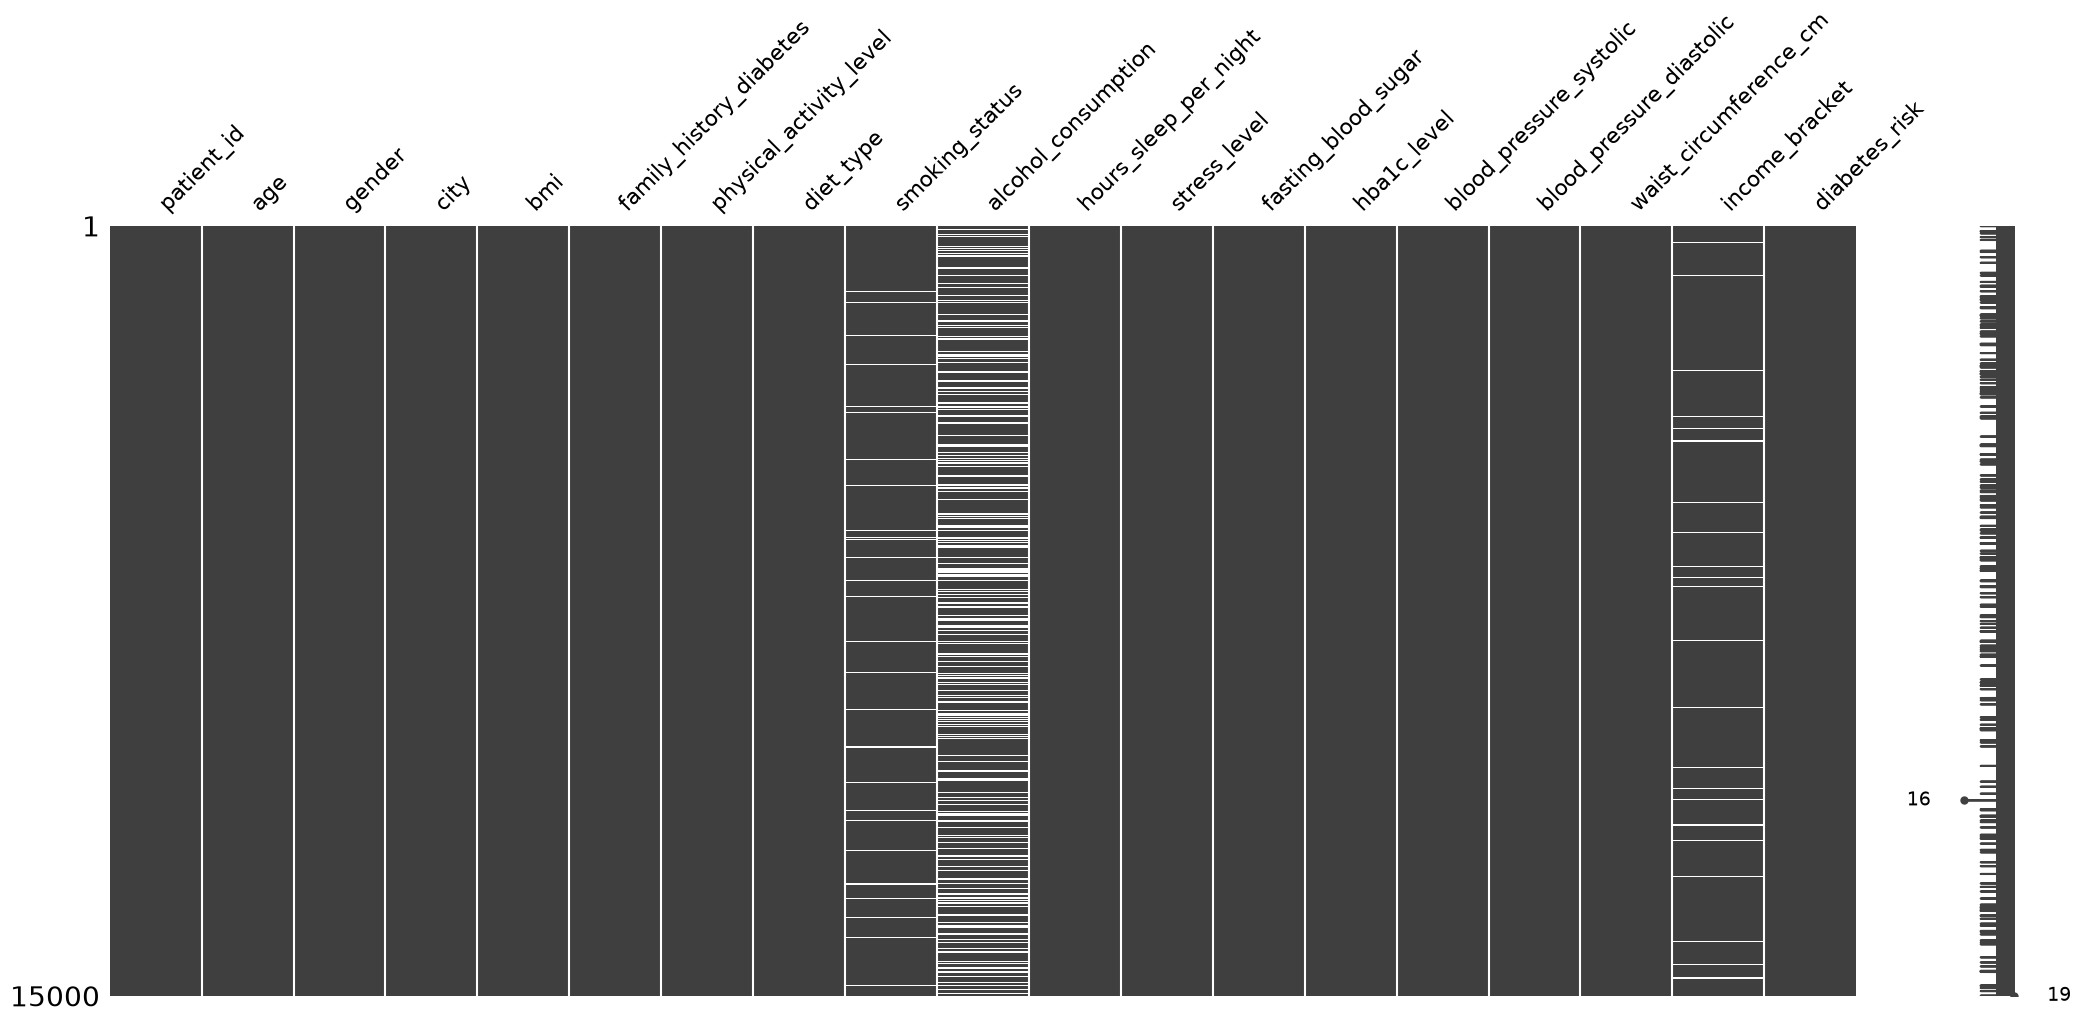

In [8]:
# Handling missing values 
import missingno as msno
msno.matrix(raw_data)

<Axes: >

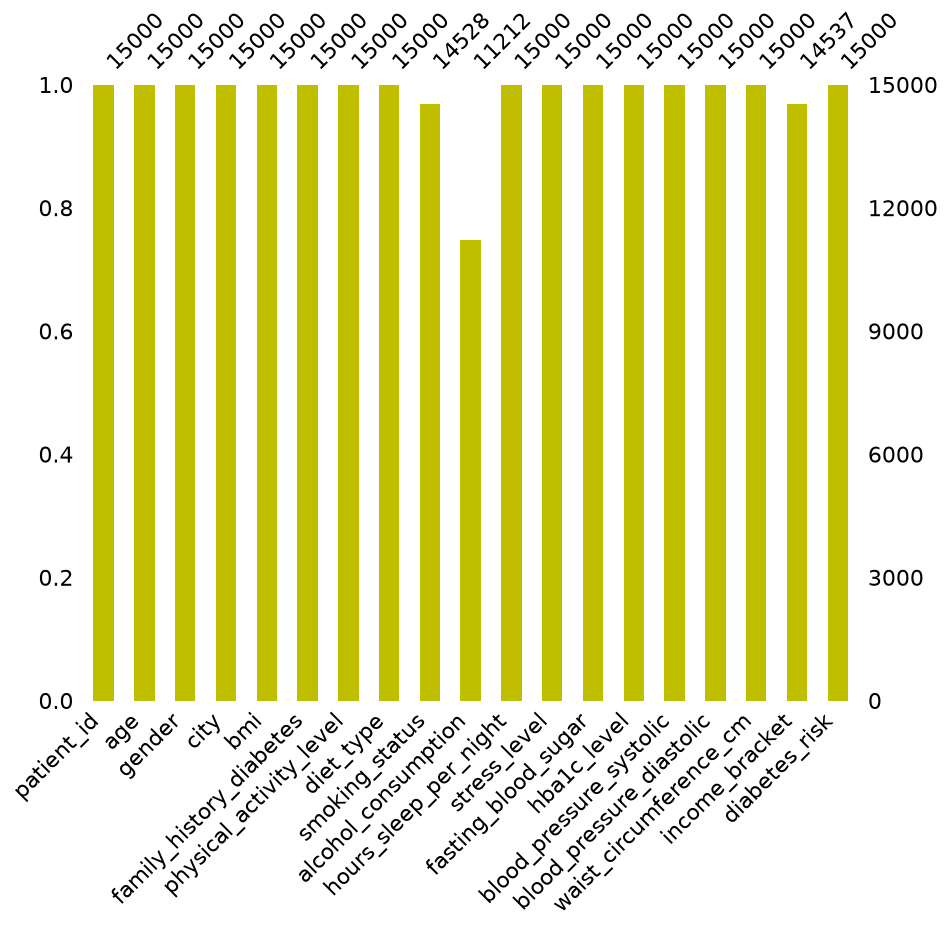

In [10]:
msno.bar(raw_data, color = 'y', figsize = (10,8))


In [ ]:
total = raw_data.isnull().sum().sort_values(ascending=False)
percent = ((raw_data.isnull().sum()/raw_data.isnull().count())*100).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data



,Total,Percent
alcohol_consumption,3788,25.253333
smoking_status,472,3.146667
income_bracket,463,3.086667
gender,0,0.000000
age,0,0.000000
patient_id,0,0.000000
city,0,0.000000
physical_activity_level,0,0.000000
family_history_diabetes,0,0.000000
diet_type,0,0.000000


In [16]:
raw_data.head()

,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low


#### Observations:
- over 10% of the data is missing, so can't go ahead with row deletion 
- there is also a chance that the missing values are not random (some patients may be embarrassed to put down alchohol or smoking consumption)

Conclusion: best to go ahead with imputation to avoid bias, or missing important information 

<Axes: xlabel='alcohol_consumption'>

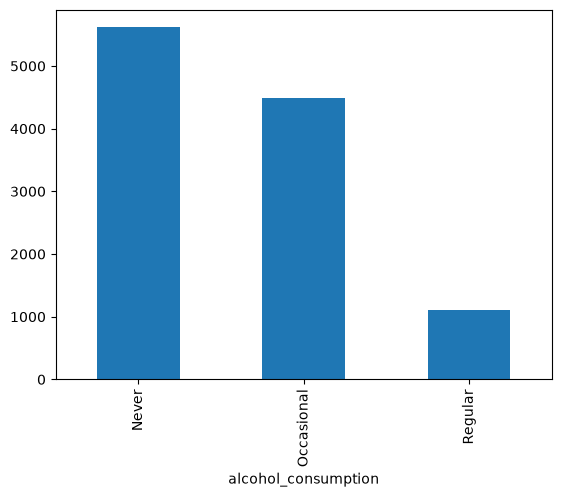

In [ ]:
# Categorical features so we need to look at distribution differently
raw_data['alcohol_consumption'].value_counts().plot(kind='bar')



<Axes: xlabel='smoking_status'>

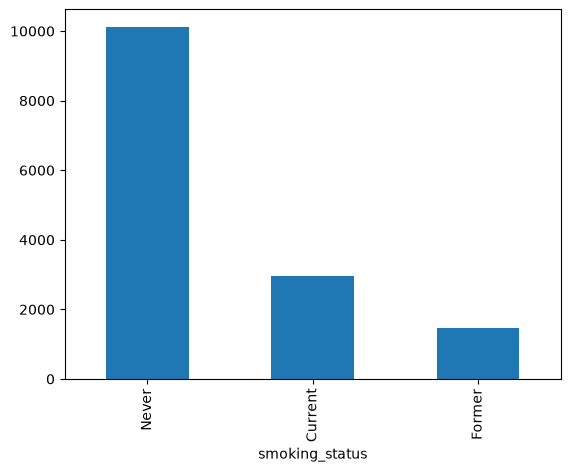

In [24]:
raw_data['smoking_status'].value_counts().plot(kind='bar')


<Axes: xlabel='income_bracket'>

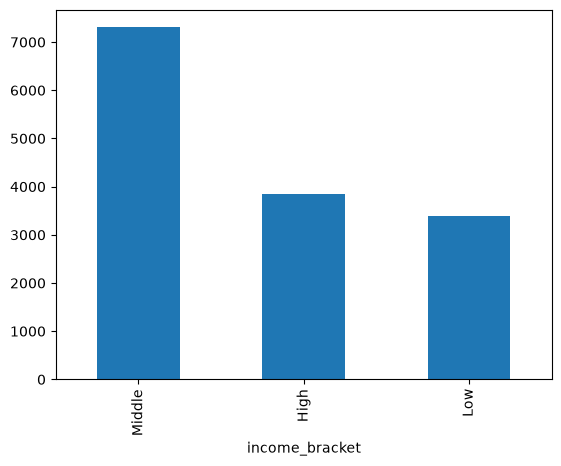

In [25]:
raw_data['income_bracket'].value_counts().plot(kind='bar')


#### Observations
- For smoking, skewed towards lower levels of smoking
- For drinking, skewed towards lower levels of drinking
- For income, skewed to middle levels of income

Conclusion: could use mode imputation for the most popular value, OR create it's own category. Perhaps the fact that patients didn't put down their levels of smoking/drinking could be an indicator (shame of admitting smoking/drinking) - and we don't want to rule this out as a random missing value. 

We can't do median imputation as these are categorical variables

- For smoking: <5-10% missing, so can go for mode imputation
- For drinking: Since we have >20% missing for alcohol would be best to create a new 'missing' category. 
- For income: <5-10% missing, so can go for mode imputation


Future: I could use KNN imputation for higher missing value precision (see this paper: https://www.sciencedirect.com/science/article/pii/S2352914823002289)

### Imputation

In [ ]:
# Simple imputation for later 
'''
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("categorical", categorical_pipeline, categorical_columns)
])
'''

In [ ]:
# Mode imputing smoking, income
# might have to update this to simpleimputer so it only applied to trained data, not test  bc of data leakage 
# for now we are just doing EDA, so will stick to this 
categorical_cols = ['smoking_status', 'income_bracket']
for col in categorical_cols:
    raw_data[col] = raw_data[col].fillna(raw_data[col].mode()[0])

In [29]:
# Missing category alcohol consumption 
raw_data['alcohol_consumption'] = raw_data['alcohol_consumption'].fillna('Missing')

In [30]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  str    
 3   city                      15000 non-null  str    
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  str    
 6   physical_activity_level   15000 non-null  str    
 7   diet_type                 15000 non-null  str    
 8   smoking_status            15000 non-null  str    
 9   alcohol_consumption       15000 non-null  str    
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_pressure_sy

<Axes: xlabel='alcohol_consumption'>

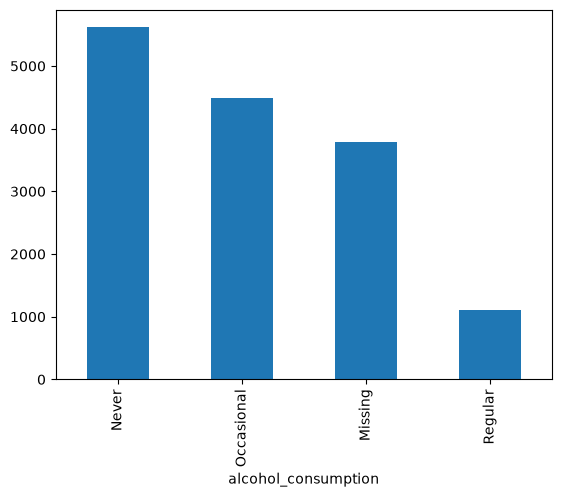

In [33]:
# Checking distribution 

raw_data['alcohol_consumption'].value_counts().plot(kind='bar')


<Axes: xlabel='smoking_status'>

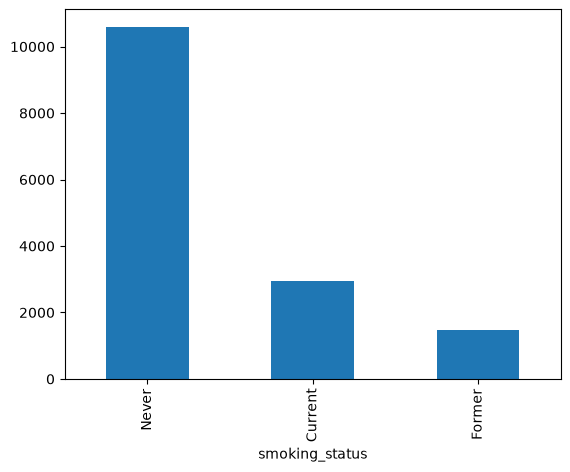

In [34]:
raw_data['smoking_status'].value_counts().plot(kind='bar')


<Axes: xlabel='income_bracket'>

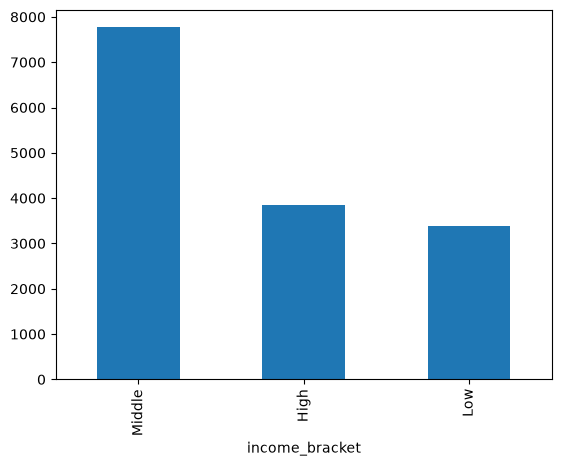

In [35]:
raw_data['income_bracket'].value_counts().plot(kind='bar')

Observation: seems like distributions are fairly similar to before for smoking and incomem

## Data Exploration

In [ ]:
# Correlation Matrix 

